# 03 PCA / SVD Dimensionality Reduction

This notebook evaluates dimensionality reduction through TruncatedSVD and compares model performance before and after reducing the feature space. The purpose is to test whether a lower-dimensional representation can preserve most predictive information while reducing training time or improving model stability.

The preprocessing pipeline creates a sparse, high-dimensional feature matrix because categorical variables are one-hot encoded. Standard PCA requires centering the data and is less convenient for sparse matrices because centering can destroy sparsity and increase memory use. TruncatedSVD is therefore more appropriate: it factorises the feature matrix directly into a smaller set of orthogonal components that approximate the original structure without requiring explicit centering.


In [1]:
import os
import sys
import time

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append(os.path.abspath('..'))

RANDOM_STATE = 42
SAMPLE_SIZE = 50000

%matplotlib inline
sns.set_theme(style='whitegrid')


In [2]:
from sklearn.base import clone
from sklearn.model_selection import train_test_split

from src.models import get_models
from src.pca_svd import apply_pca
from src.preprocessing import build_preprocess
from src.train import evaluate_model, train_and_log


In [3]:
df = pd.read_csv('../datasets/ratings.csv')
df = df[df['score'] > 0]
df = df[df['num_watched_episodes'] <= 10000]
df = df[df['num_watched_episodes'] >= 0]
df = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE)

TARGET = 'score'
X_df = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy()

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=RANDOM_STATE
)

preprocess = build_preprocess(df, TARGET)
X_train = preprocess.fit_transform(X_train_df)
X_test = preprocess.transform(X_test_df)

models = get_models('regression')


## Baseline Model Comparison Before SVD

This section trains the regression models on the full preprocessed feature representation. These baseline results are necessary because dimensionality reduction can only be evaluated meaningfully against the unreduced feature space. The metrics recorded here include RMSE, MAE, R2, and fit time for each model.

The baseline table should be interpreted as the reference point for later comparison. If a model already trains quickly and achieves low RMSE, SVD may provide limited benefit. If a model is slow or sensitive to high-dimensional sparse inputs, SVD may reduce computational cost. The baseline therefore establishes both predictive quality and computational burden before any information is compressed.


In [4]:
baseline_rows = []
while mlflow.active_run():
    mlflow.end_run()
with mlflow.start_run(nested=True, run_name='03_baseline_before_svd'):
    for name, model in models.items():
        fitted, fit_time = train_and_log(name, clone(model), X_train, y_train)
        metrics = evaluate_model(f'{name}_baseline', fitted, X_test, y_test)
        baseline_rows.append({'model': name, 'fit_time_baseline': fit_time, **{f'{k}_baseline': v for k, v in metrics.items()}})

df_baseline = pd.DataFrame(baseline_rows)
display(df_baseline.sort_values('rmse_baseline'))


2026/05/27 20:01:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/27 20:01:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/27 20:01:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/27 20:01:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

,model,fit_time_baseline,rmse_baseline,mae_baseline,r2_baseline
9,GradientBoosting,2.121329,1.741506,1.335977,0.095023
8,RandomForest,1.557993,1.744971,1.335922,0.091418
7,DecisionTree,0.033971,1.747127,1.337254,0.089172
10,MLP_single,7.307344,1.747610,1.348179,0.088668
11,MLP_multi,7.794319,1.748326,1.341989,0.087921
0,Linear,0.016360,1.756628,1.359012,0.079239
1,Ridge,0.011940,1.756639,1.359032,0.079227
2,Lasso,0.080005,1.756929,1.359458,0.078923
6,KNN,0.153232,1.916603,1.443840,-0.096105
4,SVR_rbf,3.295615,2.511992,2.176281,-0.882886


## SVD Reduction

TruncatedSVD approximates the original feature matrix by decomposing it into singular vectors and singular values. Intuitively, it finds latent directions that explain the largest amount of variation in the encoded data. Each transformed component is a weighted combination of original features, so the reduced representation is less directly interpretable but often more compact.

The 95% variance threshold is chosen as a compromise between information retention and dimensionality reduction. Retaining 95% of explained variance means the reduced matrix keeps most of the measurable structure in the original feature space while discarding lower-variance directions that may contain noise or redundant information. This does not guarantee that 95% of predictive information is retained, because variance and target relevance are not identical, but it is a defensible unsupervised criterion.

The cumulative explained variance plot shows how quickly information accumulates as components are added. A steep curve indicates that relatively few components capture most of the structure, making dimensionality reduction attractive. A slow curve indicates that information is spread across many dimensions, so aggressive reduction may remove useful signals. The selected number of components printed by the code quantifies how many latent dimensions are needed to reach the 95% threshold.


Selected components: 3
Explained variance sum: 0.975022275135157


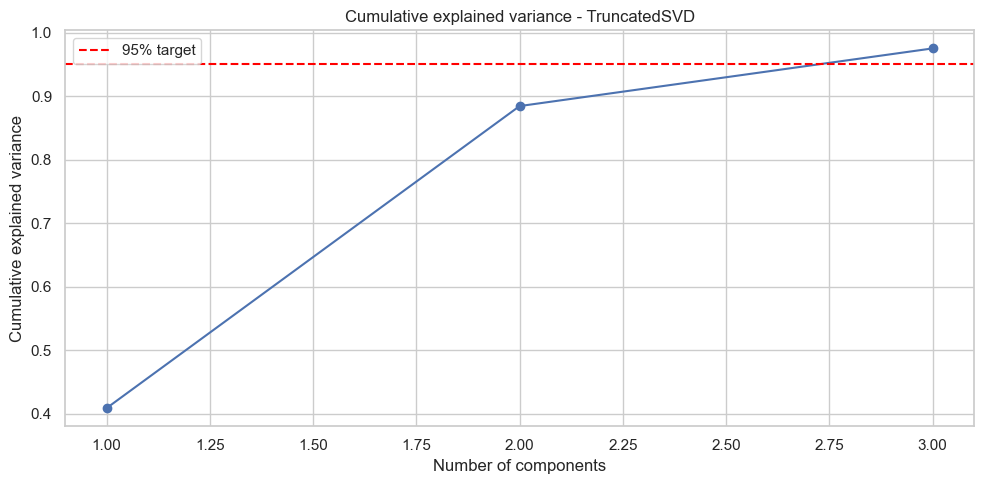

In [5]:
X_train_red, svd = apply_pca(X_train, variance=0.95)
X_test_red = svd.transform(X_test)

cumulative_variance = np.cumsum(svd.explained_variance_ratio_)
print('Selected components:', svd.n_components)
print('Explained variance sum:', cumulative_variance[-1])

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% target')
plt.title('Cumulative explained variance - TruncatedSVD')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.legend()
plt.tight_layout()
plt.savefig('../artifacts/cumulative_variance_svd.png', dpi=150, bbox_inches='tight')
plt.savefig('../artifacts/fit_time_comparison_svd.png', dpi=150, bbox_inches='tight')
plt.show()


## Models After SVD and Comparison

After SVD, the same regression model families are trained on the reduced representation. The comparison table contains baseline and SVD versions of RMSE and fit time, plus deltas that show whether SVD improved or worsened each metric. A negative RMSE delta means SVD improved predictive error, while a positive delta means the reduced representation lost information relevant to score prediction.

Linear, Ridge, and Lasso models may benefit from SVD if the original one-hot encoded features are highly correlated or noisy. However, they may also lose interpretability because the components no longer correspond to individual original variables. SVR and K-NN often benefit computationally from lower dimensionality because distance and kernel calculations become cheaper, but their accuracy depends on whether the SVD components preserve meaningful neighbourhoods. Tree-based models may not always benefit from SVD because trees naturally select useful splits from original features, and dense SVD components can make tree decisions less interpretable. MLP models may train faster on fewer inputs, but performance depends on whether the reduced components contain enough signal for the network to learn.

The side-by-side fit-time chart compares `fit_time_baseline` and `fit_time_svd` for each model. If SVD reduces fit time while maintaining similar RMSE, it is beneficial for practical deployment. If SVD worsens RMSE substantially, the time saving may not justify the information loss. The final RMSE and fit-time plots summarise these tradeoffs visually.

Dimensionality reduction is most useful when the feature space is very large, sparse, redundant, or computationally expensive. It is less useful when the original features are already compact, when interpretability is essential, or when low-variance components still contain target-relevant information. The results of this notebook therefore guide whether the final predictive application should use the full preprocessing pipeline or a compressed SVD representation.


In [6]:
svd_rows = []
while mlflow.active_run():
    mlflow.end_run()
with mlflow.start_run(nested=True, run_name='03_models_after_svd'):
    for name, model in models.items():
        fitted, fit_time = train_and_log(name, clone(model), X_train_red, y_train)
        metrics = evaluate_model(f'{name}_svd', fitted, X_test_red, y_test)
        svd_rows.append({'model': name, 'fit_time_svd': fit_time, **{f'{k}_svd': v for k, v in metrics.items()}})

df_svd = pd.DataFrame(svd_rows)
comparison = df_baseline.merge(df_svd, on='model')
comparison['rmse_delta'] = comparison['rmse_svd'] - comparison['rmse_baseline']
comparison['fit_time_delta'] = comparison['fit_time_svd'] - comparison['fit_time_baseline']
display(comparison.sort_values('rmse_svd'))


2026/05/27 20:04:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/27 20:04:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/27 20:04:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/27 20:04:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

,model,fit_time_baseline,rmse_baseline,mae_baseline,r2_baseline,fit_time_svd,rmse_svd,mae_svd,r2_svd,rmse_delta,fit_time_delta
8,RandomForest,1.557993,1.744971,1.335922,0.091418,1.444920,1.746892,1.336897,0.089417,0.001921,-0.113074
9,GradientBoosting,2.121329,1.741506,1.335977,0.095023,2.632095,1.749788,1.343448,0.086396,0.008282,0.510766
7,DecisionTree,0.033971,1.747127,1.337254,0.089172,0.078529,1.752474,1.339078,0.083588,0.005347,0.044558
10,MLP_single,7.307344,1.747610,1.348179,0.088668,15.305985,1.788947,1.381290,0.045046,0.041337,7.998641
11,MLP_multi,7.794319,1.748326,1.341989,0.087921,15.812333,1.791032,1.373730,0.042819,0.042706,8.018014
0,Linear,0.016360,1.756628,1.359012,0.079239,0.008269,1.799990,1.391122,0.033220,0.043362,-0.008091
1,Ridge,0.011940,1.756639,1.359032,0.079227,0.004267,1.799991,1.391122,0.033219,0.043352,-0.007674
2,Lasso,0.080005,1.756929,1.359458,0.078923,0.026028,1.800047,1.391112,0.033159,0.043118,-0.053977
6,KNN,0.153232,1.916603,1.443840,-0.096105,0.039569,1.898457,1.448940,-0.075447,-0.018146,-0.113663
4,SVR_rbf,3.295615,2.511992,2.176281,-0.882886,3.038404,2.598052,2.269710,-1.014109,0.086060,-0.257211


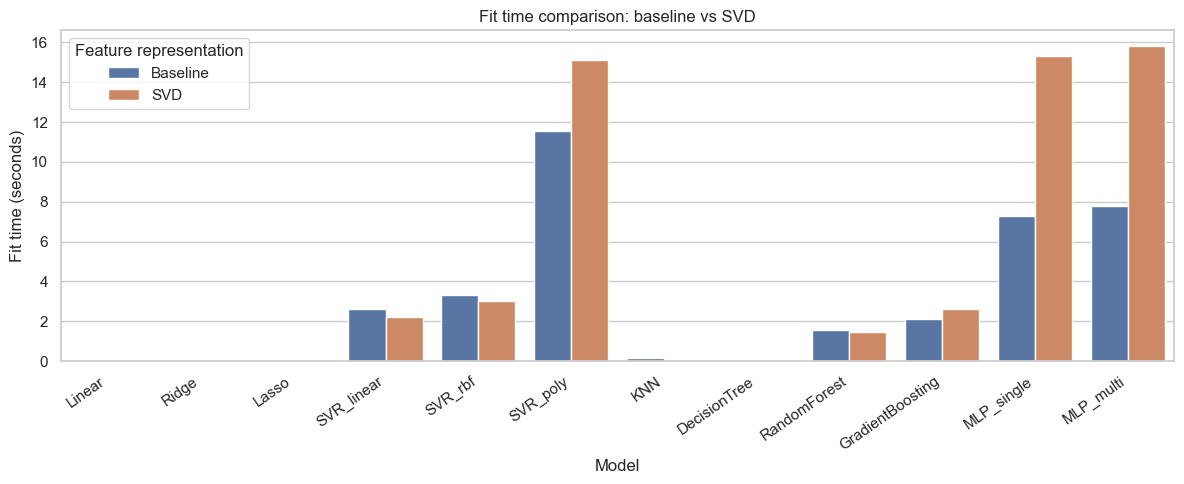

In [7]:
fit_time_comparison = comparison[['model', 'fit_time_baseline', 'fit_time_svd']].melt(
    id_vars='model',
    value_vars=['fit_time_baseline', 'fit_time_svd'],
    var_name='representation',
    value_name='fit_time_seconds',
)
fit_time_comparison['representation'] = fit_time_comparison['representation'].map({
    'fit_time_baseline': 'Baseline',
    'fit_time_svd': 'SVD',
})

plt.figure(figsize=(12, 5))
sns.barplot(
    data=fit_time_comparison,
    x='model',
    y='fit_time_seconds',
    hue='representation',
)
plt.title('Fit time comparison: baseline vs SVD')
plt.xlabel('Model')
plt.ylabel('Fit time (seconds)')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Feature representation')
plt.tight_layout()
plt.show()


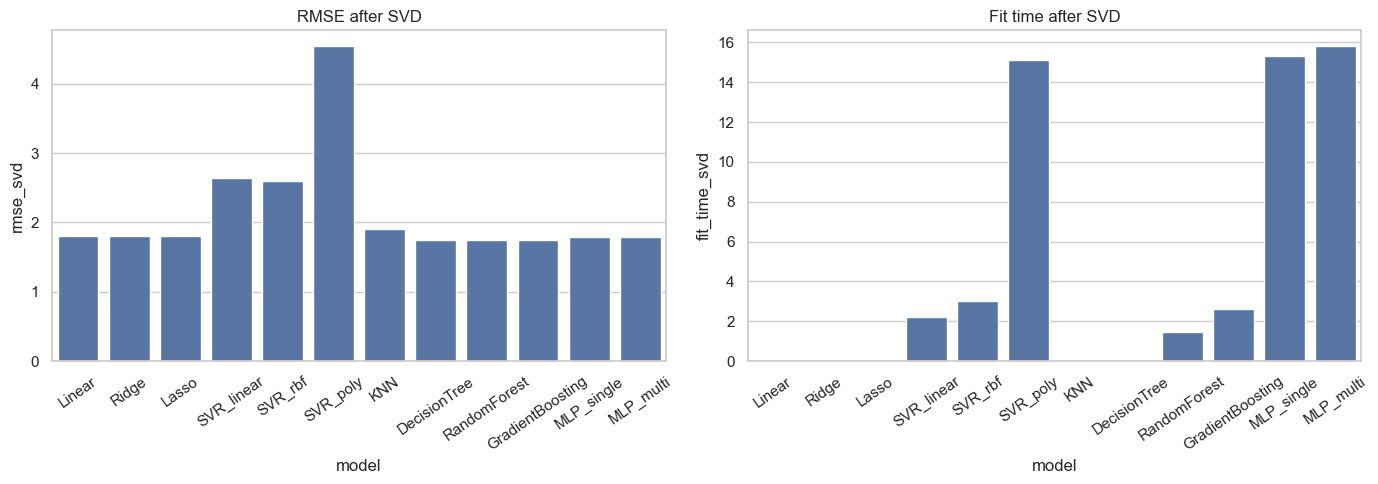

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=comparison, x='model', y='rmse_svd', ax=axes[0])
axes[0].set_title('RMSE after SVD')
axes[0].tick_params(axis='x', rotation=35)
sns.barplot(data=comparison, x='model', y='fit_time_svd', ax=axes[1])
axes[1].set_title('Fit time after SVD')
axes[1].tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()


In [9]:
from pathlib import Path
Path('../artifacts').mkdir(exist_ok=True)
comparison.to_csv('../artifacts/pca_comparison.csv', index=False)
